In [1]:
import sys
sys.executable

'd:\\Deep Learning\\Handwritten-Digit-Recognition-on-MNIST-dataset\\my_env\\Scripts\\python.exe'

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras import Sequential

 

In [3]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

 

In [14]:
y_test.shape

(10000,)

In [5]:
# Preprocess - LeNet expects 32x32 input and normalized values
X_train = tf.pad(X_train, [[0,0],[2,2],[2,2]])
X_test  = tf.pad(X_test,  [[0,0],[2,2],[2,2]])

X_train = tf.cast(X_train, tf.float32) / 255.0  # cast then normalize
X_test  = tf.cast(X_test,  tf.float32) / 255.0

X_train = X_train[..., tf.newaxis]  # add channel dim
X_test  = X_test[...,  tf.newaxis]

In [6]:
# LeNet-5 Architecture (LeCun's original design)
model = Sequential([
    Conv2D(6,  kernel_size=5, activation='tanh', input_shape=(32,32,1)),
    AveragePooling2D(pool_size=2),
    Conv2D(16, kernel_size=5, activation='tanh'),
    AveragePooling2D(pool_size=2),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84,  activation='tanh'),
    Dense(10,  activation='softmax')
])
 

d:\Deep Learning\Handwritten-Digit-Recognition-on-MNIST-dataset\my_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
# Train
history = model.fit(X_train, y_train, epochs=15, validation_split=0.2)
 

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9249 - loss: 0.2528 - val_accuracy: 0.9636 - val_loss: 0.1233
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9710 - loss: 0.0956 - val_accuracy: 0.9730 - val_loss: 0.0917
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9794 - loss: 0.0658 - val_accuracy: 0.9757 - val_loss: 0.0736
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9851 - loss: 0.0491 - val_accuracy: 0.9762 - val_loss: 0.0785
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9883 - loss: 0.0389 - val_accuracy: 0.9818 - val_loss: 0.0629
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9903 - loss: 0.0306 - val_accuracy: 0.9815 - val_loss: 0.0613
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9913 - loss: 0.0265 - val_accuracy: 0.9823 - val_loss: 0.0618
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9924 - loss: 0.02

In [10]:
 # Evaluate
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9817 - loss: 0.0683


[0.06831805408000946, 0.9817000031471252]

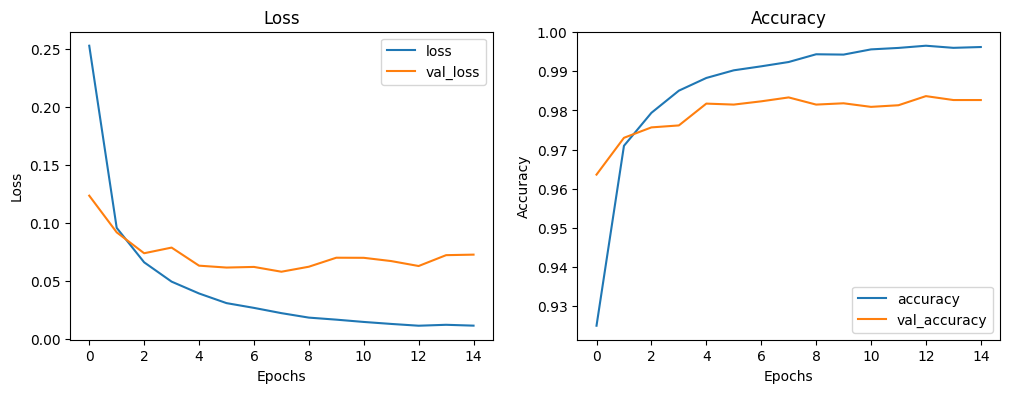

In [12]:
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

 
plt.show()